In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, root_mean_squared_error

# sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


- 타이타닉 승객의 개인 및 탑승 정보(성별, 연령, 객실 등급 등)를 기반으로 생존 여부(survived: 생존 1 / 사망 0)를 예측하는 이진 분류(Binary Classification) 모델을 구축하고자 합니다.

- 입력(특성): 탑승객 인적/탑승 정보 (pclass, sex, age, sibsp, parch, fare, embarked 등)

- 출력(정답): 생존 여부 (1: 생존, 0: 사망)





[문제 0] 프로젝트 목표 정의 (5점)

1. 데이터 수집·전처리부터 모델 학습, 성능 평가까지 이어지는 머신러닝 파이프라인의 전체 구조를 명확히 제시하세요.

2. 학습(Train) 및 평가(Test) 과정에서 발생할 수 있는 데이터 누수(Data Leakage)를 방지하기 위한 데이터 분리 및 처리 전략을 포함하여 기술하세요.





[문제 1] 데이터 확인 및 EDA (10점)

1. 데이터의 행/열 개수, 컬럼명, 결측치 개수(컬럼별) 요약을 작성하고, 이상치를 탐색를 각 컬럼의 이상치로 판단하거나 이상치로 보지 않은 근거를 서술하세요(5점)

2. Survived 클래스 비율(생존/사망 비율)을 계산하고 해석하세요. (5점)
                                                                                    `
 



[문제 2] 다음 조건을 만족하도록 전처리를 설계하세요. (20점)

1. 수치형/범주형 변수를 구분하라. (5점)

2. 결측치 처리 전략을 각각 제시하세요. (예: age, embarked 등) (5점)

3. 범주형 인코딩 방법(원-핫 등)과 수치형 스케일링 필요 여부를 판단하고 근거를 서술하세요. (5점)

4. 스케일링을 표준화로 할지 정규화로 할지 판단 근거를 서술하세요. (5점)

 



[문제 3] 데이터 분리 및 검증 전략 (15점)

1. 학습/테스트 데이터를 분리하세요. (7점)

2. 분리 시 stratify(계층화) 적용 여부를 결정하고 이유를 설명하세요. (8점)

 



[문제 4] 모델 학습 (20점)

1. 기본 모델 1개 이상: (예: Logistic Regression, Lasso, Ridge, RandomForest 등) (5점)

2. 모델 학습 및 예측까지 이어지는 전체 흐름과 각 단계별 핵심 코드를 작성하세요. (10점)

3. 파라미터와 하이퍼파라미터의 차이를 서술하고, 하이퍼파라미터 튜닝을 “최소 1개 파라미터”만이라도 시도하세요.(5점)




[문제 5] 평가 및 리포트 (20점)

1. Accuracy, Precision, Recall, F1 중 최소 2개 이상 사용하여 모델을 평가하세요. (10점)

2. Confusion Matrix 해석하세요. (5점)  

3. 어떤 오류가 더 치명적인지(예: 생존자를 사망으로 예측 vs 반대) 상황을 가정해 서술하세요. (5점)

 



[문제 6] 최종 제출물 구성 (10점)

1. 데이터 요약(EDA 결과 핵심 3가지)하여 서술하세요. (3점)

2. 전처리 전략 요약(결측/인코딩/스케일링)하여 서술하세요. (3점)

3. 모델 선택 이유와 학습 설정(튜닝 포함)을 요약하여 서술하세요. (2점)

4. 최종 성능 지표 및 해석과 개선 아이디어 1개 이상 서술하세요. (2점)

In [7]:
base_path = r"C:\kdt_0900_lsu\ml\resource\datasets"
file_name = r"titanic.csv"

file_path = os.path.join(base_path, file_name)

In [8]:
df = pd.read_csv(file_path)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df.shape

출력 결과는 (행,열) 이므로, 891열 12행이다

(891, 12)

In [10]:
df.columns

데이터의 어떤 변수들이 있는지 확인한다

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [12]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

타이타닉 데이터의 이상치를 탐색할 때는 먼저 각 컬럼의 데이터 유형과 변수의 의미를 확인해야 한다. 수치형 변수인 Age, SibSp, Parch, Fare는 IQR이나 Boxplot 등을 이용하여 일반적인 데이터 범위에서 벗어난 값을 탐색할 수 있다.

Age의 경우 일반적인 나이 범위를 크게 벗어난 값이 있는지 확인할 수 있지만, 실제로 고령의 승객이 존재할 수 있으므로 통계적인 기준만으로 이상치라고 단정하지 않고 실제 발생 가능한 값인지 함께 판단해야 한다. SibSp와 Parch 역시 값이 크더라도 대가족이 함께 탑승한 경우 실제로 발생할 수 있으므로 단순히 큰 값이라는 이유만으로 이상치로 판단해서는 안 된다. Fare는 운임을 나타내는 수치형 변수이므로 IQR을 이용해 이상치 후보를 탐색할 수 있으며, 높은 운임이 실제로 발생할 수 있는 데이터인지 확인한 후 판단해야 한다.

반면 PassengerId와 Ticket은 승객을 구분하기 위한 식별자 성격의 데이터이므로 값의 크기를 기준으로 이상치를 판단하지 않는다. Survived는 0과 1로 이루어진 이진 변수이며, Pclass는 1, 2, 3의 좌석 등급을 나타내므로 일반적인 수치형 변수처럼 IQR을 적용하여 이상치를 판단하지 않는다. Name과 Sex, Cabin, Embarked는 문자열 또는 범주형 데이터이므로 수치적인 이상치보다는 정해진 범주에 해당하지 않는 값이나 잘못 입력된 값이 있는지를 확인해야 한다.

따라서 이상치는 단순히 통계적인 범위를 벗어났다는 이유만으로 판단하는 것이 아니라, 각 컬럼의 데이터 유형과 실제 의미를 함께 고려하여 판단해야 한다.


In [ ]:
컬럼별 이상치 판단
컬럼	이상치 판단	근거
PassengerId	이상치로 보지 않음	승객을 구분하기 위한 식별자이므로 값의 크기 자체가 데이터의 특성을 나타내지 않음
Survived	이상치로 보지 않음	0과 1로 구성된 생존 여부 변수이므로 0, 1은 정상적인 값
Pclass	이상치로 보지 않음	1, 2, 3으로 구성된 좌석 등급 변수이며 각 값이 의미를 가지므로 단순히 수치 크기로 이상치를 판단하지 않음
Name	이상치로 보지 않음	승객의 이름을 나타내는 문자열 데이터이므로 수치형 이상치 탐색 대상이 아님
Sex	이상치로 보지 않음	성별을 나타내는 범주형 데이터이므로 정해진 범주 외의 값이 있는지를 확인하는 것이 중요함
Age	이상치 탐색 필요	나이는 수치형 변수이므로 IQR이나 Boxplot을 이용해 일반적인 범위를 벗어난 값을 확인할 수 있음. 다만 실제 고령 승객일 가능성이 있으므로 통계적 기준만으로 이상치라고 단정하면 안 됨
SibSp	이상치 탐색 필요	함께 탑승한 형제·배우자 수를 나타내는 수치형 변수이므로 지나치게 큰 값이 있는지 확인할 수 있음. 실제 대가족일 가능성도 고려해야 함
Parch	이상치 탐색 필요	함께 탑승한 부모·자녀 수를 나타내므로 큰 값이 있더라도 실제 가족 구성원 수일 가능성을 고려해야 함
Ticket	이상치로 보지 않음	티켓 번호를 나타내는 식별성 데이터이므로 숫자처럼 보이더라도 값의 크기를 기준으로 이상치를 판단하지 않음
Fare	이상치 탐색 필요	운임을 나타내는 수치형 변수이므로 IQR이나 Boxplot으로 지나치게 높거나 낮은 값을 확인할 수 있음. 다만 좌석 등급이나 티켓 조건 등에 따라 높은 운임이 실제로 발생할 수 있음
Cabin	이상치로 보지 않음	객실 번호를 나타내는 범주형/문자열 데이터이며, 결측치가 많은 것이 특징이지 특정 값의 크기를 이용해 이상치를 판단하는 데이터는 아님
Embarked	이상치로 보지 않음	탑승 항구를 나타내는 범주형 변수이므로 정해진 항구 범주가 아닌 값이 있는지를 확인해야 함

In [14]:
drop_columns = ["PassengerId","Name","Ticket","Cabin","Embarked"]
titanic_df = df.drop(drop_columns,axis=1)

In [15]:
titanic_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000
887,1,1,female,19.0,0,0,30.0000
888,0,3,female,NaN,1,2,23.4500
889,1,1,male,26.0,0,0,30.0000


In [16]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(4), object(1)
memory usage: 48.9+ KB


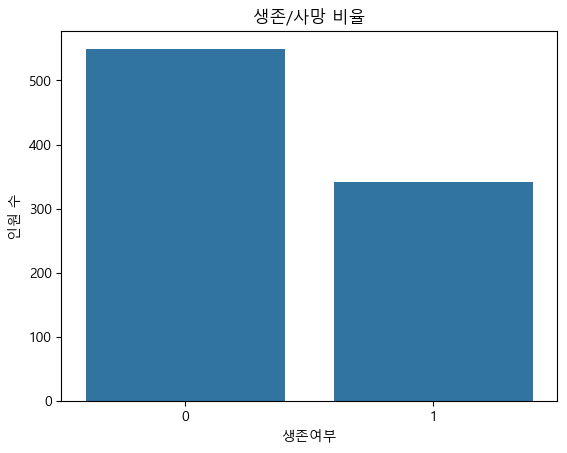

In [21]:
sns.countplot(titanic_df, x="Survived")

plt.title("생존/사망 비율")
plt.xlabel("생존여부")
plt.ylabel("인원 수")

plt.show()

In [23]:
drop_columns = ["PassengerId","Name","Ticket","Cabin","Embarked"]
titanic_df = df.drop(drop_columns,axis=1)

In [24]:
titanic_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000
887,1,1,female,19.0,0,0,30.0000
888,0,3,female,NaN,1,2,23.4500
889,1,1,male,26.0,0,0,30.0000


In [25]:
X = titanic_df.drop("Survived", axis=1)
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,male,22.0,1,0,7.2500
1,1,female,38.0,1,0,71.2833
2,3,female,26.0,0,0,7.9250
3,1,female,35.0,1,0,53.1000
4,3,male,35.0,0,0,8.0500


In [26]:
y = titanic_df["Survived"]
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)
print(X_train.shape, X_test. shape, y_train.shape, y_test.shape)

(712, 6) (179, 6) (712,) (179,)
